# What are the top 5 most voted events for each event type (PLE/PPV, Televised, Non-Televised)?

In [ ]:
# Libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.image import imread
from matplotlib.patches import Patch
import duckdb
import pandas as pd

In [ ]:
# Establish Connection
conn = duckdb.connect("/Users/marietolteca/Documents/MEDS/WWE-database/wwe_database.db")
cur = conn.cursor()

In [ ]:
cur.execute("""
SELECT EventType, Event, TotalVotes
FROM (
    SELECT 
        e.EventType,
        e.Event,
        SUM(m.CageMatchRatingVotes) AS TotalVotes,
        ROW_NUMBER() OVER (PARTITION BY e.EventType ORDER BY SUM(m.CageMatchRatingVotes) DESC) AS rn
    FROM events e
    JOIN match_rating m ON e.Date = m.Date AND e.Promotion = m.Promotion
    GROUP BY e.EventType, e.Event
) sub
WHERE rn <= 5                          -- top 5 per EventType only
  AND TotalVotes IS NOT NULL
ORDER BY EventType, TotalVotes DESC;
""")

In [ ]:
cur.execute("""

""")

BinderException: Binder Error: Table "m" does not have a column named "TotalVotes"

Candidate bindings: : "Date"

LINE 4:        SUM(m.TotalVotes) AS TotalVotes
                   ^

In [13]:
# Save query from all superstars in Wrestlemania with most viewed total votes
df = cur.df()

# Print the first five rows
df

,EventType,Event,TotalVotes
0,Non-Televised,WWE NXT Live,70923.0
1,Non-Televised,WWE Live,37803.0
2,Non-Televised,WWE World At WrestleMania,17219.0
3,Non-Televised,WWE WrestleMania Axxess,16629.0
4,Non-Televised,WWE SuperShow,6096.0
5,PLE/PPV,WWE WrestleMania,79995.0
6,PLE/PPV,WWE NXT Stand & Deliver,38584.0
7,PLE/PPV,WWE SummerSlam,36250.0
8,PLE/PPV,WWE Royal Rumble,27684.0
9,PLE/PPV,WWE Money In The Bank,26692.0


# Draft of `EventTypes`

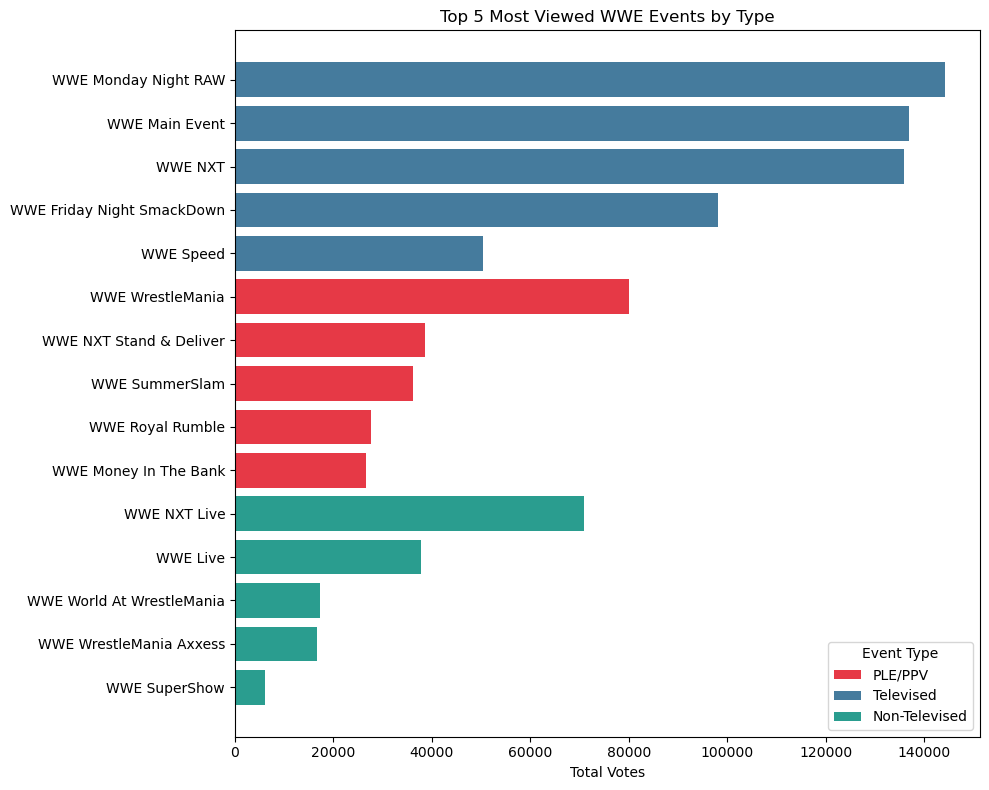

In [15]:
colors = {"PLE/PPV": "#e63946", "Televised": "#457b9d", "Non-Televised": "#2a9d8f"}

df_clean = df.dropna(subset=["TotalVotes"])
df_sorted = df_clean.sort_values(["EventType", "TotalVotes"], ascending=[True, True])

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    df_sorted["Event"],
    df_sorted["TotalVotes"],
    color=df_sorted["EventType"].map(colors)
)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, title="Event Type")

ax.set_xlabel("Total Votes")
ax.set_title("Top 5 Most Viewed WWE Events by Type")
plt.tight_layout()
plt.show()

### Draft 2

In [13]:
colors = {"PLE/PPV": "#e63946", "Televised": "#457b9d", "Non-Televised": "#2a9d8f"}
bg_color = "#022340"

df_sorted = df.sort_values("TotalVotes", ascending=True)

# Remove WWE infront of Events
df_sorted["Event"] = df_sorted["Event"].str.replace("WWE ", "", regex=False)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bars = ax.barh(
    df_sorted["Event"],
    df_sorted["TotalVotes"],
    color=df_sorted["EventType"].map(colors),
    edgecolor="white",
    linewidth=0.8
)

# Value labels in K format
for bar in bars:
    val = bar.get_width()
    ax.text(val + 500, bar.get_y() + bar.get_height() / 2,
            f"{val/1000:.0f}K", va="center", fontsize=10, color="white")

# X axis in K format
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

ax.set_xlabel("Total Votes", color="white", fontsize=12)

ax.set_title("Top 5 Most Voted WWE Events by Type (2015–2025)",
             color="white", fontsize=15, fontweight="bold")
ax.tick_params(colors="white")

ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

legend_elements = [mpatches.Patch(facecolor=v, label=k) for k, v in colors.items()]

ax.legend(handles=legend_elements, title="Event Type", facecolor=bg_color,
          labelcolor="white", edgecolor="white", title_fontsize=9)

ax.title.set_color("white")


ax.legend(handles=legend_elements, title="Event Type", facecolor=bg_color,
          labelcolor="white", edgecolor="white",
          loc="lower right", bbox_to_anchor=(1, 0.25)).get_title().set_color("white")

# Add LOGO
logo = imread("WWE-logo.png")
logo_ax = fig.add_axes([0.75, 0.02, 0.15, 0.3])  # [left, bottom, width, height]
logo_ax.imshow(logo)
logo_ax.axis("off")


plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

/var/folders/7j/l4df3nhs4jg2_5kxg79fnwww0000gn/T/ipykernel_1111/1564233059.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


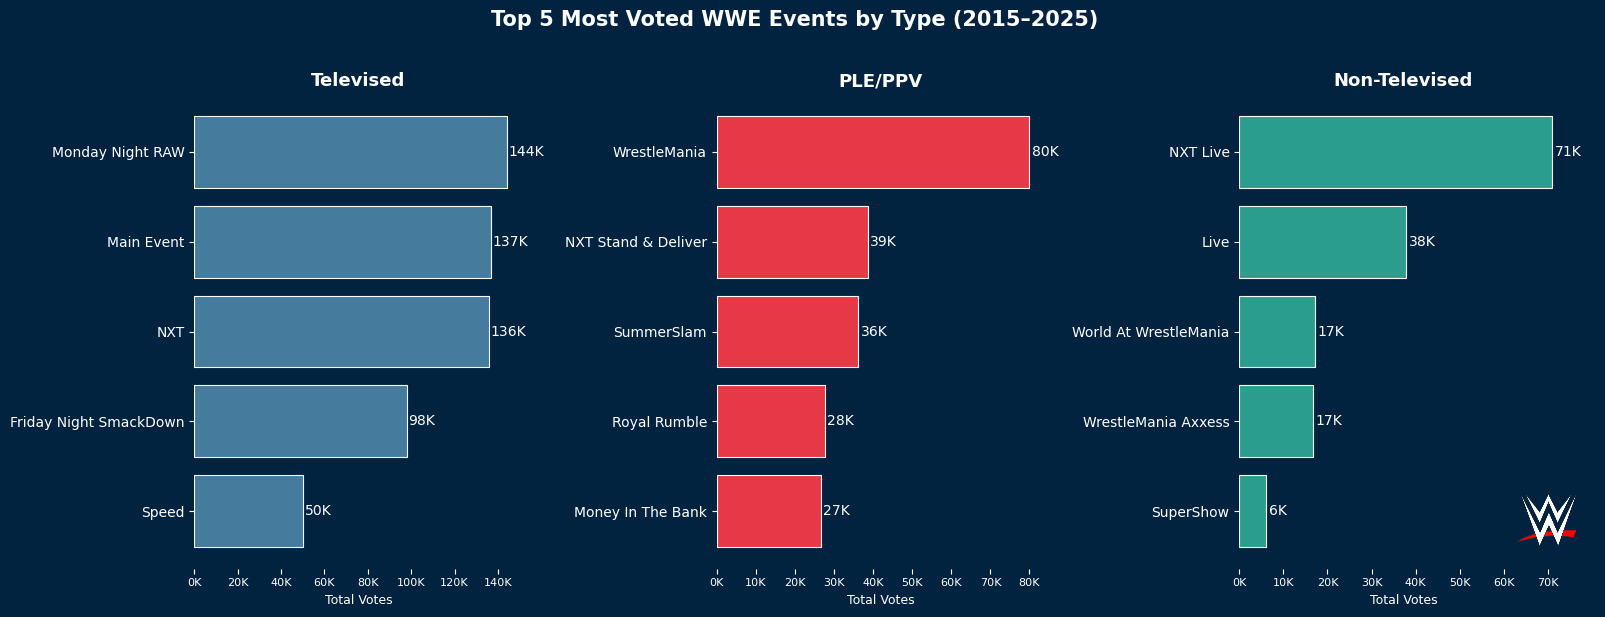

In [ ]:

# Set color by EventTypes
colors = {"PLE/PPV": "#e63946", "Televised": "#457b9d", "Non-Televised": "#2a9d8f"}

# Set Background color
bg_color = "#022340"

# Set legend categories
event_types = ["Televised", "PLE/PPV", "Non-Televised"]


# Start Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

fig.patch.set_facecolor(bg_color)

for ax, etype in zip(axes, event_types):
    subset = df[df["EventType"] == etype].sort_values("TotalVotes", ascending=True)

    # Remove WWE infront of Events
    subset["Event"] = subset["Event"].str.replace("WWE ", "", regex=False) 

    ax.set_facecolor(bg_color)
    bars = ax.barh(subset["Event"], subset["TotalVotes"],
                   color=colors[etype], edgecolor="white", linewidth=0.8)

    # Value labels in K format - Makes x-axis easier to read
    for bar in bars:
        val = bar.get_width()
        ax.text(val + 600, bar.get_y() + bar.get_height() / 2,
               f"{val/1000:.0f}K", va="center", fontsize=10, color="white")
        
    # Format x-axis to match K labels
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

    

    # Small critiques
    ax.set_title(etype, color="white", fontsize=13, fontweight="bold")
    ax.tick_params(colors="white", labelsize=8)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.set_xlabel("Total Votes", color="white", fontsize=9)
    ax.xaxis.label.set_color("white")
    ax.tick_params(axis="x", colors="white", labelsize=8)
    ax.tick_params(axis="y", colors="white", labelsize=10)


fig.suptitle("Top 5 Most Voted WWE Events by Type (2015–2025)",
             color="white", fontsize=15, fontweight="bold", y=1.02)

# Add LOGO
logo = imread("WWE-logo.png")
logo_ax = fig.add_axes([0.94, 0.02, 0.06, 0.3])  # [left, bottom, width, height]
logo_ax.imshow(logo)
logo_ax.axis("off")


plt.tight_layout()
plt.show()

# Close Connection

In [14]:
conn.close()